# BioCLIP 2 inference

### Gets our zero shot values from our images. However does not produce any embeddings that are stored in this notebook. 

In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from src.utils.paths import load_paths
paths = load_paths()


In [2]:
import torch

# Device setup for GPU acceleration
# device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")  # uncomment for Mac
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Importing the 2 JSON files and paths

In [3]:
import pandas as pd
import json
import os
from PIL import Image
import sys
import bioclip
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# ---- View mode ----------------------------------------------------------
# Which view(s) to evaluate BioCLIP zero-shot on:
#   "both"    -> final_data_cleaned.json; per-specimen dorsal acc + ventral acc
#                + highest-confidence-of-the-two (original behavior).
#   "dorsal"  -> dorsal_only_data.json;   per-specimen dorsal-only acc.
#   "ventral" -> ventral_only_data.json;  per-specimen ventral-only acc.
# Run-dir gets a "_<mode>" suffix so dorsal-only / ventral-only / both
# results land in separate folders and can be compared side-by-side.
VIEW_MODE = "ventral"

_VIEW_JSON = {
    "both":    "final_data_cleaned.json",
    "dorsal":  "dorsal_only_data.json",
    "ventral": "ventral_only_data.json",
}
assert VIEW_MODE in _VIEW_JSON, f"VIEW_MODE must be one of {list(_VIEW_JSON)}"

# Load your prepared data (VIEW_MODE picks which JSON)
DATA_PATH = paths['processed_dir'] / _VIEW_JSON[VIEW_MODE]
CLASS_NAMES_PATH = paths['class_names_json']

with open(DATA_PATH, 'r') as f:
    image_data = json.load(f)

with open(CLASS_NAMES_PATH, 'r') as f:
    class_names = json.load(f)

print(f"[VIEW_MODE={VIEW_MODE}] Loaded {DATA_PATH.name}")
print(f"First few entries in the data:", image_data[:5])
print(f"Printing the class names:", class_names[:7])

print(f"Loaded {len(image_data)} image records.")
print(f"Loaded {len(class_names)} unique class names.")


[VIEW_MODE=ventral] Loaded ventral_only_data.json
First few entries in the data: [{'image_path': '/fs/ess/PAS2136/jjivandas/projects/tick_classification_project/data/raw/idi/100-01-02.jpg', 'true_label': 'Dermacentor variabilis', 'sample_id': '100-01', 'view': 'ventral', 'sex': 'Female', 'life_stage': 'Adult', 'attached': nan, 'pathogen_result': 'negative', 'pathogen': 'none', 'tick_condition': 'Fed'}, {'image_path': '/fs/ess/PAS2136/jjivandas/projects/tick_classification_project/data/raw/idi/102-01-02.jpg', 'true_label': 'Ixodes scapularis', 'sample_id': '102-01', 'view': 'ventral', 'sex': 'Female', 'life_stage': 'Adult', 'attached': nan, 'pathogen_result': 'negative', 'pathogen': 'none', 'tick_condition': 'Unfed'}, {'image_path': '/fs/ess/PAS2136/jjivandas/projects/tick_classification_project/data/raw/idi/104-01-02.jpg', 'true_label': 'Ixodes scapularis', 'sample_id': '104-01', 'view': 'ventral', 'sex': 'Female', 'life_stage': 'Adult', 'attached': nan, 'pathogen_result': 'negative', 

In [4]:
# === Determine species label set from raw data (no inference needed) ===
from collections import defaultdict

MIN_N = 50  # minimum specimens to include a species

# Count valid specimens per species. The "valid" criterion depends on VIEW_MODE
# so that single-view modes don't accidentally filter out everything: in dorsal/
# ventral mode each specimen has only the chosen view, so requiring "both" would
# give counts of 0 and an empty large_species_names list.
required_views = {
    "both":    {"dorsal", "ventral"},
    "dorsal":  {"dorsal"},
    "ventral": {"ventral"},
}[VIEW_MODE]

by_views = defaultdict(lambda: defaultdict(set))
for r in image_data:
    by_views[r['true_label']][r['sample_id']].add(r['view'].strip().lower())

specimen_counts = {
    sp: sum(1 for views in sids.values() if required_views.issubset(views))
    for sp, sids in by_views.items()
}

# Species with N >= MIN_N, sorted by descending count
large_species_names = sorted(
    [sp for sp, n in specimen_counts.items() if n >= MIN_N],
    key=lambda sp: specimen_counts[sp], reverse=True
)

# Verification summary
print(f"[VIEW_MODE={VIEW_MODE}] required views: {sorted(required_views)}")
print(f"Total species in dataset: {len(specimen_counts)}")
print(f"\nSpecies INCLUDED in BioCLIP inference (N >= {MIN_N}):")
for sp in large_species_names:
    print(f"  {sp}: {specimen_counts[sp]} valid specimens")

print(f"\nSpecies EXCLUDED (N < {MIN_N}):")
for sp, n in sorted(specimen_counts.items(), key=lambda x: -x[1]):
    if n < MIN_N:
        print(f"  {sp}: {n} valid specimens")


[VIEW_MODE=ventral] required views: ['ventral']
Total species in dataset: 5

Species INCLUDED in BioCLIP inference (N >= 50):
  Dermacentor variabilis: 318 valid specimens
  Ixodes scapularis: 174 valid specimens
  Amblyomma americanum: 124 valid specimens
  Haemaphysalis leporispalustris: 53 valid specimens
  Haemaphysalis longicornis: 52 valid specimens

Species EXCLUDED (N < 50):


## Setting up BioClip with the data

In [5]:

# Import the specific pybioclip classifier
from bioclip import CustomLabelsClassifier

# Initialize classifier with only the 8 species (N >= MIN_N)
# This ensures BioCLIP and the SVM solve the same closed classification problem
classifier = CustomLabelsClassifier(cls_ary=large_species_names, device=device)

print(f"BioCLIP classifier initialized with {len(large_species_names)} species:")
for sp in large_species_names:
    print(f"  {sp}")

print(f"BioCLIP classifier initialized successfully on {device}.")

BioCLIP classifier initialized with 5 species:
  Dermacentor variabilis
  Ixodes scapularis
  Amblyomma americanum
  Haemaphysalis leporispalustris
  Haemaphysalis longicornis
BioCLIP classifier initialized successfully on cuda.


## Testing bioclip on the first image 

In [6]:
# Test BioClip on the first image in your tick dataset
first_item = image_data[0]
image_path = first_item["image_path"]
true_label = first_item["true_label"]

# Run prediction
predictions = classifier.predict(image_path)
for pred in predictions:
    print(f"{pred['classification']:30s}  |  Score: {round(pred['score'], 4)}")

# Show top prediction
top_prediction = predictions[0]["classification"]
score = predictions[0]["score"]

print("\nPredicted:", top_prediction)
print("Confidence:", round(score, 4))
print("True label:", true_label)
print("✅ Correct!" if top_prediction == true_label else "❌ Incorrect.")

  0%|                                                                                                                                                                  | 0/1 [00:00<?, ?images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.71images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.71images/s]

Dermacentor variabilis          |  Score: 0.9904
Ixodes scapularis               |  Score: 0.0085
Haemaphysalis longicornis       |  Score: 0.0006
Haemaphysalis leporispalustris  |  Score: 0.0004
Amblyomma americanum            |  Score: 0.0001

Predicted: Dermacentor variabilis
Confidence: 0.9904
True label: Dermacentor variabilis
✅ Correct!


In [7]:
# Test BioClip on the first image in your tick dataset
first_item = image_data[0]
image_path = first_item["image_path"]
true_label = first_item["true_label"]

# Run prediction
predictions = classifier.predict(image_path)
for pred in predictions:
    print(f"{pred['classification']:30s}  |  Score: {round(pred['score'], 4)}")

# Show top prediction
top_prediction = predictions[0]["classification"]
score = predictions[0]["score"]

print("\nPredicted:", top_prediction)
print("Confidence:", round(score, 4))
print("True label:", true_label)
print("✅ Correct!" if top_prediction == true_label else "❌ Incorrect.")

  0%|                                                                                                                                                                  | 0/1 [00:00<?, ?images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.01images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.01images/s]

Dermacentor variabilis          |  Score: 0.9904
Ixodes scapularis               |  Score: 0.0085
Haemaphysalis longicornis       |  Score: 0.0006
Haemaphysalis leporispalustris  |  Score: 0.0004
Amblyomma americanum            |  Score: 0.0001

Predicted: Dermacentor variabilis
Confidence: 0.9904
True label: Dermacentor variabilis
✅ Correct!


## Running all the images on BioClip, getting the dorsal, ventral and total accuracies.

inference done on dorsal and ventral separately and then we get the accuracies

In [8]:
from collections import defaultdict

# Group entries by sample_id
samples = defaultdict(dict)
for entry in image_data:
    samples[entry['sample_id']][entry['view']] = entry

# In "both" mode we report dorsal / ventral / highest-confidence accuracy.
# In single-view modes only the chosen view is meaningful, so the other two
# trackers stay empty and we just report that single accuracy.
dorsal_correct = 0
ventral_correct = 0
highest_conf_correct = 0
total = 0

# Per-class stats
dorsal_class_correct = defaultdict(int)
dorsal_class_total = defaultdict(int)
ventral_class_correct = defaultdict(int)
ventral_class_total = defaultdict(int)
highest_conf_class_correct = defaultdict(int)
highest_conf_class_total = defaultdict(int)

# Storing predictions and ground truths for a confusion matrix
y_true = []
y_pred = []

# Which views must each specimen have to be evaluated
REQUIRED_VIEWS = {
    "both":    {"dorsal", "ventral"},
    "dorsal":  {"dorsal"},
    "ventral": {"ventral"},
}[VIEW_MODE]

for sample_id, views in samples.items():
    if not REQUIRED_VIEWS.issubset(views.keys()):
        continue  # missing the view(s) we need for this mode

    # Only classify specimens from the filtered species set
    any_view = next(iter(views.values()))
    if any_view['true_label'] not in large_species_names:
        continue

    if VIEW_MODE == "both":
        dorsal = views['dorsal']
        ventral = views['ventral']

        # Predict dorsal
        dorsal_preds = classifier.predict(dorsal['image_path'])
        dorsal_top = dorsal_preds[0]['classification']
        dorsal_score = dorsal_preds[0]['score']
        dorsal_true = dorsal['true_label']

        # Predict ventral
        ventral_preds = classifier.predict(ventral['image_path'])
        ventral_top = ventral_preds[0]['classification']
        ventral_score = ventral_preds[0]['score']
        ventral_true = ventral['true_label']

        # Dorsal accuracy
        dorsal_class_total[dorsal_true] += 1
        if dorsal_top == dorsal_true:
            dorsal_correct += 1
            dorsal_class_correct[dorsal_true] += 1

        # Ventral accuracy
        ventral_class_total[ventral_true] += 1
        if ventral_top == ventral_true:
            ventral_correct += 1
            ventral_class_correct[ventral_true] += 1

        # Highest confidence
        if dorsal_score >= ventral_score:
            best_pred = dorsal_top
            best_true = dorsal_true
        else:
            best_pred = ventral_top
            best_true = ventral_true
        highest_conf_class_total[best_true] += 1
        if best_pred == best_true:
            highest_conf_correct += 1
            highest_conf_class_correct[best_true] += 1

        y_true.append(best_true)
        y_pred.append(best_pred)
    else:
        # Single-view mode: only predict on the chosen view
        view_name = VIEW_MODE  # "dorsal" or "ventral"
        entry = views[view_name]
        preds = classifier.predict(entry['image_path'])
        top = preds[0]['classification']
        true = entry['true_label']

        if view_name == "dorsal":
            dorsal_class_total[true] += 1
            if top == true:
                dorsal_correct += 1
                dorsal_class_correct[true] += 1
        else:
            ventral_class_total[true] += 1
            if top == true:
                ventral_correct += 1
                ventral_class_correct[true] += 1

        # In single-view mode "highest confidence" == the single prediction
        y_true.append(true)
        y_pred.append(top)

    total += 1

# Report — skip metrics for views we did not evaluate
if VIEW_MODE in ("both", "dorsal"):
    print(f"Dorsal accuracy: {dorsal_correct/total:.3f}")
if VIEW_MODE in ("both", "ventral"):
    print(f"Ventral accuracy: {ventral_correct/total:.3f}")
if VIEW_MODE == "both":
    print(f"Highest confidence accuracy: {highest_conf_correct/total:.3f}")
print(f"Total evaluated samples: {total}  (VIEW_MODE={VIEW_MODE})")

# Per-class breakdowns
if dorsal_class_total:
    dorsum = 0
    print("\nPer-class dorsal accuracy:")
    for cls in sorted(dorsal_class_total):
        acc = dorsal_class_correct[cls] / dorsal_class_total[cls]
        dorsum += acc
        print(f"{cls:30s} | {acc:.3f}")
    dorsal_macro_acc = dorsum / len(dorsal_class_total)
    print(f"\nDorsal Macro-Accuracy: {dorsal_macro_acc:.3f}")

if ventral_class_total:
    vensum = 0
    print("\nPer-class ventral accuracy:")
    for cls in sorted(ventral_class_total):
        acc = ventral_class_correct[cls] / ventral_class_total[cls]
        vensum += acc
        print(f"{cls:30s} | {acc:.3f}")
    ven_macro_acc = vensum / len(ventral_class_total)
    print(f"\nVentral Macro-Accuracy: {ven_macro_acc:.3f}")

if highest_conf_class_total:
    hcasum = 0
    print("\nPer-class highest confidence accuracy:")
    for cls in sorted(highest_conf_class_total):
        acc = highest_conf_class_correct[cls] / highest_conf_class_total[cls]
        hcasum += acc
        print(f"{cls:30s} | {acc:.3f}")
    hca_macro_acc = hcasum / len(highest_conf_class_total)
    print(f"\nHighest Confidence Macro-Accuracy: {hca_macro_acc:.3f}")


  0%|                                                                                                                                                                  | 0/1 [00:00<?, ?images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.57images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.57images/s]

  0%|                                                                                                                                                                  | 0/1 [00:00<?, ?images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.54images/s]

...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.96images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.88images/s]

  0%|                                                                                                                                                                  | 0/1 [00:00<?, ?images/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.28images/s]

Ventral accuracy: 0.678
Total evaluated samples: 721  (VIEW_MODE=ventral)

Per-class ventral accuracy:
Amblyomma americanum           | 0.040
Dermacentor variabilis         | 0.874
Haemaphysalis leporispalustris | 0.000
Haemaphysalis longicornis      | 0.865
Ixodes scapularis              | 0.925

Ventral Macro-Accuracy: 0.541


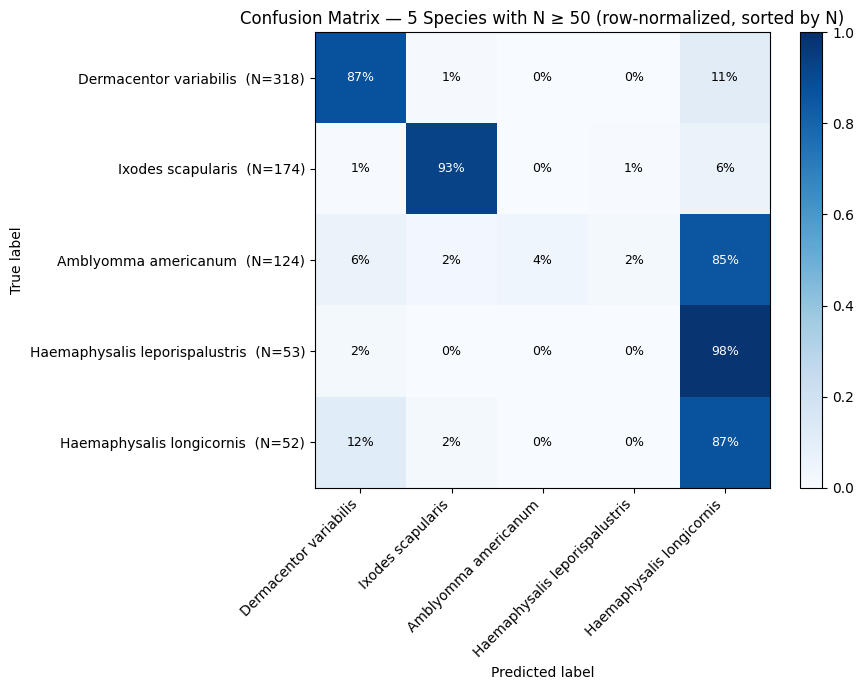

In [9]:
import numpy as np
from collections import Counter

# Sort species by descending N
counts = Counter(y_true)
sorted_labels = sorted(large_species_names, key=lambda s: counts.get(s, 0), reverse=True)

# Raw confusion matrix in sorted order
cm_raw = confusion_matrix(y_true, y_pred, labels=sorted_labels)

# Row-normalize so each row sums to 1
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sums > 0, cm_raw / row_sums, 0)

# Row labels include N=n; column labels are plain species names
y_labels = [f"{sp}  (N={counts.get(sp, 0)})" for sp in sorted_labels]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(sorted_labels)))
ax.set_yticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix — {len(sorted_labels)} Species with N ≥ 50 (row-normalized, sorted by N)')

thresh = 0.5
for i in range(len(sorted_labels)):
    for j in range(len(sorted_labels)):
        ax.text(j, i, f'{cm_norm[i, j]*100:.0f}%',
                ha='center', va='center',
                color='white' if cm_norm[i, j] > thresh else 'black',
                fontsize=9)

plt.tight_layout()
plt.show()

## Block 10b: Confusion Matrix (N ≥ 50 Species Only) - temp

In [10]:
# # === Block 10b — Confusion Matrix (Species with N ≥ 50 only) ===
# MIN_N = 50

# # Filter to species that have at least MIN_N specimens
# large_species = [sp for sp in sorted_labels if counts.get(sp, 0) >= MIN_N]

# # Filter y_true and y_pred to only include specimens from those species
# y_true_filtered = [t for t, p in zip(y_true, y_pred) if t in large_species]
# y_pred_filtered = [p for t, p in zip(y_true, y_pred) if t in large_species]

# # Raw confusion matrix in the same descending-N order
# cm_raw_f = confusion_matrix(y_true_filtered, y_pred_filtered, labels=large_species)

# # Row-normalize
# row_sums_f = cm_raw_f.sum(axis=1, keepdims=True)
# cm_norm_f = np.where(row_sums_f > 0, cm_raw_f / row_sums_f, 0)

# # Y-axis labels with N counts
# y_labels_f = [f"{sp}  (N={counts.get(sp, 0)})" for sp in large_species]

# fig, ax = plt.subplots(figsize=(9, 7))
# im = ax.imshow(cm_norm_f, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
# fig.colorbar(im, ax=ax)

# ax.set_xticks(range(len(large_species)))
# ax.set_yticks(range(len(large_species)))
# ax.set_xticklabels(large_species, rotation=45, ha='right')
# ax.set_yticklabels(y_labels_f)
# ax.set_xlabel('Predicted label')
# ax.set_ylabel('True label')
# ax.set_title(f'Confusion Matrix — ({len(large_species)}) Species with N ≥ {MIN_N} (row-normalized, sorted by N)')

# thresh = 0.5
# for i in range(len(large_species)):
#     for j in range(len(large_species)):
#         ax.text(j, i, f'{cm_norm_f[i, j]*100:.0f}%',
#                 ha='center', va='center',
#                 color='white' if cm_norm_f[i, j] > thresh else 'black',
#                 fontsize=9)

# plt.tight_layout()
# plt.show()

# print(f"Included species (N ≥ {MIN_N}): {large_species}")
# print(f"Excluded species (N < {MIN_N}): {[sp for sp in sorted_labels if sp not in large_species]}")

In [11]:

# === Save BioCLIP zero-shot results for reuse (combined figure, macro chart) ===
import numpy as np
from datetime import datetime
from sklearn.metrics import balanced_accuracy_score

BIOCLIP_RESULTS = paths['bioclip_results_dir']
# Tag the run dir with VIEW_MODE so dorsal-only / ventral-only / both runs
# never overwrite each other.
RUN_ID = datetime.now().strftime("%y%m%d_%H%M%S") + f"_{VIEW_MODE}"
RUN_DIR = BIOCLIP_RESULTS / "runs" / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Macro accuracy for the filtered species
bioclip_macro_acc = balanced_accuracy_score(y_true, y_pred)
print(f"[VIEW_MODE={VIEW_MODE}] BioCLIP zero-shot macro accuracy ({len(sorted_labels)} species): {bioclip_macro_acc:.3f}")

# Save predictions and confusion matrix data
save_path = RUN_DIR / "bioclip_results.npz"
np.savez(
    save_path,
    y_true=np.array(y_true, dtype=object),
    y_pred=np.array(y_pred, dtype=object),
    large_species=np.array(sorted_labels, dtype=object),
    counts=np.array([counts.get(sp, 0) for sp in sorted_labels]),
    macro_acc=np.array([bioclip_macro_acc]),
    view_mode=np.array([VIEW_MODE]),
)

# Write pointer to latest run so notebook 03 can always find it.
# Per-mode latest pointer so notebook 03 (or comparisons) can fetch the right run.
latest_path = BIOCLIP_RESULTS / f"latest_run_{VIEW_MODE}.txt"
latest_path.write_text(str(save_path))
# Also update the generic latest_run.txt (back-compat for existing callers)
(BIOCLIP_RESULTS / "latest_run.txt").write_text(str(save_path))

print(f"[SAVE] {save_path}")
print(f"[SAVE] {latest_path.name} -> {save_path}")


[VIEW_MODE=ventral] BioCLIP zero-shot macro accuracy (5 species): 0.541
[SAVE] /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/bioclip_zeroshot/runs/260518_001351_ventral/bioclip_results.npz
[SAVE] latest_run_ventral.txt -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/bioclip_zeroshot/runs/260518_001351_ventral/bioclip_results.npz


In [12]:
# # Creating Separate 2x2 Matrices for Amblyomma maculatum vs Amblyomma americanum
# # Define the labels for Amblyomma species
# amb_labels = ["Amblyomma maculatum", "Amblyomma americanum"]

# # Filter y_true and y_pred to only include Amblyomma samples
# amb_true = [true for true, pred in zip(y_true, y_pred) if true in amb_labels]
# amb_pred = [pred for true, pred in zip(y_true, y_pred) if true in amb_labels]

# # Generate confusion matrix for Amblyomma species
# cm_amb = confusion_matrix(amb_true, amb_pred, labels=amb_labels)

# # Plot
# disp_amb = ConfusionMatrixDisplay(confusion_matrix=cm_amb, display_labels=amb_labels)
# fig, ax = plt.subplots(figsize=(5, 4))
# disp_amb.plot(cmap='Blues', xticks_rotation=45, ax=ax)
# plt.title("Confusion Matrix - Amblyomma Species")
# plt.show()

# print("Amblyomma Confusion Matrix (raw counts):")
# print(cm_amb)



In [13]:
# # Define the labels for Ixodes species
# ix_labels = ["Ixodes", "Ixodes scapularis"]

# # Filter y_true and y_pred to only include Ixodes samples
# ix_true = [true for true, pred in zip(y_true, y_pred) if true in ix_labels]
# ix_pred = [pred for true, pred in zip(y_true, y_pred) if true in ix_labels]

# # Generate confusion matrix for Ixodes species
# cm_ix = confusion_matrix(ix_true, ix_pred, labels=ix_labels)

# # Plot
# disp_ix = ConfusionMatrixDisplay(confusion_matrix=cm_ix, display_labels=ix_labels)
# fig, ax = plt.subplots(figsize=(5, 4))
# disp_ix.plot(cmap='Blues', xticks_rotation=45, ax=ax)
# plt.title("Confusion Matrix - Ixodes Species")
# plt.show()

# print("Ixodes Confusion Matrix (raw counts):")
# print(cm_ix)
